**`PHOTOREALISTIC HAND AVATAR TEXTURING WITH PALMAR AND DORSAL HAND VIEWS `**

Photorealistic texturing of a 3D hand model requires strong semantic understanding of hand anatomy. Existing image-based texture generation methods often lack awareness of the structural differences between the palmar and dorsal sides of the hand, causing texture repetition, incorrect anatomical placement, and loss of contextual details.

To address this limitation, we employ a ControlNet-based texture generation framework conditioned on semantic maps, depth maps, and hand masks. These anatomical priors guide the diffusion process to generate semantically consistent and geometrically aligned hand textures. The generated textures are subsequently transferred to a UV texture image, which can be directly wrapped onto a standard 3D hand mesh.

****
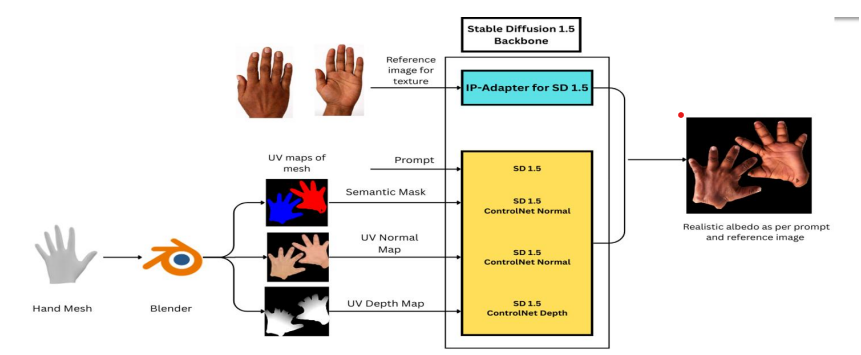
*Figure:Photorealistic Texture Generation Pipeline*

Unlike existing approaches that reconstruct a complete textured 3D hand and often require multi-view capture, optimization, and several hours of processing to achieve high-quality results, our method is lightweight and efficient. Given only a front (palmar) and back (dorsal) hand image, it generates a high-quality UV texture map in under one minute, enabling rapid creation of personalized photorealistic hand avatars for XR, gaming, telepresence, and digital human applications.

In [4]:
from google.colab import drive
drive.unmount('/content/drive')

AttributeError: module 'google.colab.drive' has no attribute 'unmount'

In [1]:
! python --version

Python 3.12.13


In [3]:
import gdown
!gdown --id "1u407yaoYpF_dK1TzibVeCTVcLo824PLf"

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1u407yaoYpF_dK1TzibVeCTVcLo824PLf
From (redirected): https://drive.google.com/uc?id=1u407yaoYpF_dK1TzibVeCTVcLo824PLf&confirm=t&uuid=e4298cae-7670-41c3-8c68-e41f6a94cd9d
To: /content/Demo.zip
100% 33.7M/33.7M [00:02<00:00, 14.4MB/s]


In [5]:
import zipfile
import os
zip_path = '/content/Demo.zip'
extract_path = '/content/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Successfully unzipped {zip_path} to {extract_path}")

Successfully unzipped /content/Demo.zip to /content/


In [6]:
!pip install diffusers
!pip install PIL
!pip install numpy
!pip install ip-adapter
!pip install opencv-python

ERROR: Could not find a version that satisfies the requirement PIL (from versions: none)
ERROR: No matching distribution found for PIL


Visualise the control inputs and the reference Dorsal and Palmar image for the model

In [23]:
import torch
import numpy as np
from PIL import Image
from diffusers import (
    StableDiffusionControlNetPipeline,
    ControlNetModel,
    DDIMScheduler
)
from ip_adapter import IPAdapter
import cv2
from google.colab.patches import cv2_imshow




# --------------------------------------------------
# CONFIG
# --------------------------------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE  = torch.float16 # Changed to float16 to reduce memory usage on GPU

BASE_MODEL = "runwayml/stable-diffusion-v1-5"
CN_NORMAL  = "lllyasviel/control_v11p_sd15_normalbae"
CN_DEPTH   = "lllyasviel/control_v11f1p_sd15_depth"

# --------------------------------------------------
# LOAD UV MAPS
# --------------------------------------------------
def load_rgb(path): return Image.open(path).convert("RGB")
def load_gray(path): return Image.open(path).convert("L")

uv_normal = load_rgb("/content/Demo/uv_bakes_Mano_Right/control_uv_normal.png") # use control_uv_ring_normal for ring textures
uv_depth  = load_gray("/content/Demo/uv_bakes_Mano_Right/uv_depth.png")
uv_mask   = load_gray("/content/Demo/uv_bakes_Mano_Right/uv_mask.png")
print("\033[1m" + "CONTROL IMAGES-UV NORMAL, UV DEPTH, UV MASK" + "\033[0m")
hstitch=np.hstack((uv_normal, uv_depth.convert('RGB'), uv_mask.convert('RGB')))
hstitch_bgr = cv2.cvtColor(hstitch, cv2.COLOR_RGB2BGR)
cv2_imshow(np.array(hstitch_bgr))

# 🔴 NEW: semantic UV map
semantic_uv = load_rgb("/content/Demo/uv_bakes_Mano_Right/semantic_mask.png")

# 🔴 NEW: reference images per semantic region
ref_back = load_rgb("/content/Demo/Back.jpg")
ref_palm = load_rgb("/content/Demo/Palm.jpg")
print("\033[1m" + "DORSAL AND PALMAR IMAGES" + "\033[0m")
hstitch=np.hstack((ref_back, ref_palm))
hstitch_bgr = cv2.cvtColor(hstitch, cv2.COLOR_RGB2BGR)
cv2_imshow(np.array(hstitch_bgr))


# ref_nail = load_rgb("input/ref_nail.png")  # optional

Output hidden; open in https://colab.research.google.com to view.

**Texture Generation with ControlNet**

Generate UV Texture using Stable diffusion conditioned on UV-Normal and UV-Depth separately for Frontal and Dorsal Images. Final Texture is obtained by merging both sides of the hand.

In [24]:


W, H = (1024,1024) # For faster execution run wit h(768,768)

uv_normal = uv_normal.resize((W, H))
uv_depth   = uv_depth.resize((W, H))
uv_mask    = uv_mask.resize((W, H))
semantic_uv = semantic_uv.resize((W, H))

# depth must be RGB
uv_depth = Image.merge("RGB", (uv_depth, uv_depth, uv_depth))

# --------------------------------------------------
# SEMANTIC MASKS (KEY ADDITION)
# --------------------------------------------------
semantic_np = np.array(semantic_uv)

palm_mask   = (semantic_np[:,:,0] > 200) & (semantic_np[:,:,1] < 50)
back_mask   = (semantic_np[:,:,2] > 200)
#finger_mask = (semantic_np[:,:,1] > 200)
#nail_mask   = (semantic_np[:,:,0] > 200) & (semantic_np[:,:,1] > 200)

def mask_to_pil(mask):
    return Image.fromarray((mask * 255).astype(np.uint8))

palm_mask_img = mask_to_pil(palm_mask)
back_mask_img = mask_to_pil(back_mask)

# --------------------------------------------------
# CONTROLNETS
# --------------------------------------------------
controlnets = [
    ControlNetModel.from_pretrained(CN_NORMAL, torch_dtype=DTYPE),
    ControlNetModel.from_pretrained(CN_DEPTH,  torch_dtype=DTYPE),
]

pipe = StableDiffusionControlNetPipeline.from_pretrained(
    BASE_MODEL,
    controlnet=controlnets,
    torch_dtype=DTYPE,
    safety_checker=None
)

pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)
# Removed pipe.to(DEVICE) as it will be replaced by enable_model_cpu_offload()

# --------------------------------------------------
# IP-ADAPTER (STYLE ANCHOR)
# --------------------------------------------------
pipe.load_ip_adapter(
    "h94/IP-Adapter",
    subfolder="models",
    weight_name="ip-adapter-plus_sd15.bin"
)
pipe.set_ip_adapter_scale(0.6)

# Re-enabled pipe.enable_model_cpu_offload() and moved it after all components are loaded
pipe.enable_model_cpu_offload()

# --------------------------------------------------
# PROMPTS (SEMANTIC-AWARE)
# --------------------------------------------------

prompt_back = (
    "UV texture map of back of hand " # for ring texture add engagement ring in prompt
    "Bright Skin,fine hair"
)

prompt_palm = (
    "UV texture map of palm of hand" # for ring texture add engagement ring in prompt
    "Realistic Human palm texture "
)

negative_prompt = (
    "lighting, shadows, highlights, specular, "
    "photo, render, camera, depth, shading"
)

# --------------------------------------------------
# RUN DIFFUSION — BACK OF HAND
# --------------------------------------------------
with torch.autocast(DEVICE):
    back_result = pipe(
        prompt=prompt_back,
        #negative_prompt=negative_prompt,
        image=[uv_normal, uv_depth],
        ip_adapter_image=ref_back,
        controlnet_conditioning_scale=[0.9, 0.6],
        guidance_scale=7,
        num_inference_steps=20,
        width=W,
        height=H,
        mask_image=back_mask_img,
        denoising_start=0.15,
    ).images[0]

# --------------------------------------------------
# RUN DIFFUSION — PALM
# --------------------------------------------------
with torch.autocast(DEVICE):
    palm_result = pipe(
        prompt=prompt_palm,
        #negative_prompt=negative_prompt,
        image=[uv_normal, uv_depth],
        ip_adapter_image=ref_palm,
        controlnet_conditioning_scale=[0.9, 0.6],
        guidance_scale=7,
        num_inference_steps=18,
        width=W,
        height=H,
        mask_image=palm_mask_img,
        denoising_start=0.15,
    ).images[0]

# --------------------------------------------------
# COMPOSITE RESULTS BY SEMANTICS
# --------------------------------------------------
back_np = np.array(back_result,dtype=np.float32)
palm_np = np.array(palm_result,dtype=np.float32)
final_np = back_np.copy()

final_np[palm_mask] = palm_np[palm_mask]

# Apply global UV mask
uv_mask_np = np.array(uv_mask) / 255.0
final_np *= uv_mask_np[..., None]

final = Image.fromarray(final_np.astype(np.uint8))
final.save("/content/Demo/hand_albedo_uv.png")

print("✅ SEMANTIC-AWARE UV ALBEDO GENERATED")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.00k [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.45G [00:00<?, ?B/s]

config.json:   0%|          | 0.00/945 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.45G [00:00<?, ?B/s]

...

models/image_encoder/model.safetensors:   0%|          | 0.00/2.53G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/520 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/18 [00:00<?, ?it/s]

✅ SEMANTIC-AWARE UV ALBEDO GENERATED


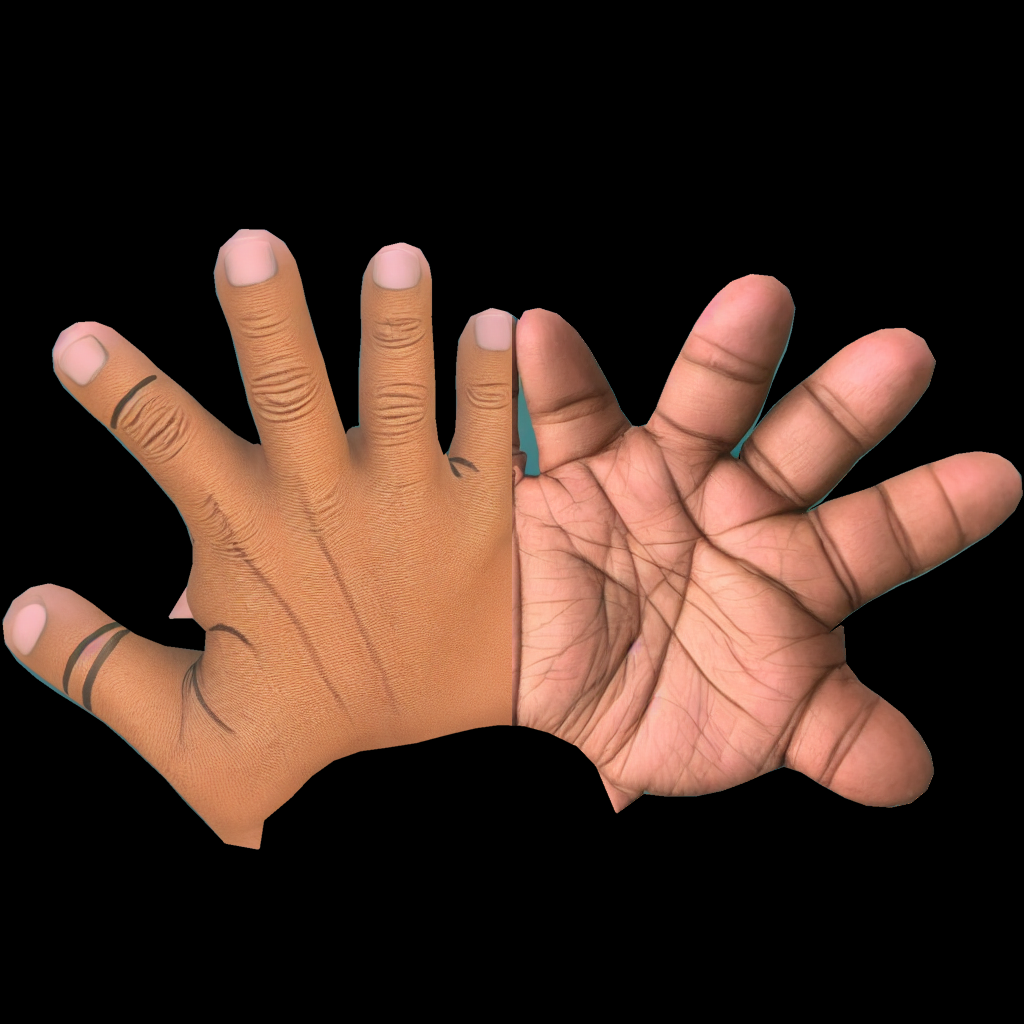

In [25]:
import cv2
from google.colab.patches import cv2_imshow
output = cv2.imread('/content/Demo/hand_albedo_uv.png')

cv2_imshow(output)

Visualise the Texture Wrapped on a Mano Mesh

In [31]:
!pip install "pyvista[jupyter]"
import pyvista as pv
pv.set_jupyter_backend('html')
pv.OFF_SCREEN = False

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.5/251.5 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.8/831.8 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 95.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 87.3 MB/s eta 0:00:00


In [32]:
texture = pv.read_texture('/content/Demo/hand_albedo_uv.png')
plotter = pv.Plotter()
mesh = pv.read("/content/Demo/MANO_UV_right.obj")
plotter.add_mesh(mesh, texture=texture)
plotter.show()

EmbeddableWidget(value='<iframe srcdoc="<!doctype html>\n<html lang=&quot;en&quot;>\n  <head>\n    <meta chars…